## APLN 552: Problem 1 of Problem Set 1: Surprisal


In [ ]:
# This installs a Python library called arpa, which is used for loading arpa format language files.
# For more information, see: https://pypi.org/project/arpa/
# Run this cell before running other cells in this notebook that use the arpa library.

!pip install arpa
import arpa

# Here are some examples of how to use arpa:

demo_model = arpa.loadf("bnc_10k_with_smoothing.arpa")[0]

# demo_model.p will give you the conditional probability of the last item given what came before
print("P(there|hi) = {:.4f}".format(demo_model.p(["hi", "there"])))

# You can pass a list of terms or a string (arpa will automatically split on spaces).
print("P(there|hi) = {:.4f}".format(demo_model.p("hi there")))

# demo_model.log_p will give you log probabilities
print("log_p(there|hi) = {:.4f}".format(demo_model.log_p(["hi", "there"])))

# demo_model.vocabulary() will return the vocabulary of the language model
print("'hi' in demo_model.vocabulary() = {:.4f}".format("hi" in demo_model.vocabulary()))

# For this problem set, the arpa models are bigram models. Arpa models will not raise an error
# when passed trigrams, but the probabilities are not correct. It actually returns the bigram
# probability of the last two tokens in the input.
print("P(there|well hi) != {:.4f}".format(demo_model.p(["well", "hi", "there"])))  # same output as demo_model.p([hi", "there"])

# Note that all input to the arpa model should be lowercase. The following will raise an error:
# demo_model.p(["Hi"])

P(there|hi) = 0.0025
P(there|hi) = 0.0025
log_p(there|hi) = -2.5984
'hi' in demo_model.vocabulary() = 1.0000
P(there|well hi) != 0.0025


## Part 1: Understanding Surprisal

Smith and Levy$^1$ explored the shape of the relationship between a word’s predictability in context and how long, on average, a comprehender spends on reading that word. In particular they were interested in the hypothesis that a word’s average reading time might be linear in the surprisal of the word (Hale, 2001; Levy, 2008):

$$\textrm{surprisal}(w_i|\textrm{Context}) = \log\frac{1}{P(w_i|\textrm{Context})} \quad\quad (1)$$

or in some other function of the word’s conditional probability. In this assignment, you will investigate this question yourself, using one of the datasets analyzed by Smith and Levy.

### (a)

Write a function to compute the surprisal of a bigram using a bigram arpa model. In the case of out of vocabulary (OOV) items (words that don't occur in our training corpus), return None.

Compute the surprisal of the word "morning" in the bigram "like morning" using the bigram arpa model trained on the British National Corpus (BNC)$^2$ with smoothing.

In [ ]:
import arpa
import numpy as np

model_with_smoothing = arpa.loadf("bnc_10k_with_smoothing.arpa")[0]
vocab = set(model_with_smoothing.vocabulary())


def compute_surprisal(arpa_model, bigram):

    (w1, w2) = bigram

    if w1 not in vocab or w2 not in vocab:
        return None
    try:

        prob_bigram = arpa_model.log_p([w1, w2])
        if prob_bigram is None or prob_bigram == 0:
            surprisal = 100000
        else:
            surprisal = np.log(1/ np.exp(prob_bigram))

    except KeyError:
        return None

    return surprisal

bigram = ("new", "york")
surprisal_value = compute_surprisal(model_with_smoothing, bigram)

if surprisal_value is not None:
    print(f"Surprisal of '{bigram[1]}' in '{bigram}': {surprisal_value:.4f}")
else:
    print("Bigram contains OOV words.")



Surprisal of 'york' in '('new', 'york')': 1.2890


### (b)

Compute the surprisal of the word "morning" in the bigram "like morning" using a bigram model trained on the BNC without smoothing. Is the surprisal of word "toast" based on the smoothing higher or lower than that of the model without smoothing? Explain why you think this is.

If it's lower, come up with an example that would have higher surprisal without smoothing than with smoothing. If it's higher, come up with an example of a bigram that would have a lower surprisal without smoothing than with smoothing.  Explain how you came up with that example.

Hint: investigate the arpa file to see which bigrams occur in the corpus.

The surprisal of "morning" without smoothing was 102.8096 as opposed to smoothing which ws 4.1098. For "toast" with smoothing it was 5.5248 and without smoothing it was 104.2246. For my example I came up with "new york" which I figured with its high frequency would have a lower surprisal rate. The surprisal for both of them was 1.2890, which showed that due to its high frequency the effect of smoothing made very little difference.

In [ ]:
import arpa
import numpy as np

model_no_smoothing = arpa.loadf("bnc_10k_no_smoothing.arpa")[0]
vocab = set(model_no_smoothing.vocabulary())


def compute_surprisal(arpa_model, bigram):
    (w1, w2) = bigram

    if w1 not in vocab or w2 not in vocab:
        return None
    try:
        prob_bigram = arpa_model.log_p([w1, w2])
        if prob_bigram is None or prob_bigram == 0:
            surprisal = 100000
        else:
            surprisal = np.log(1/ np.exp(prob_bigram))

    except KeyError:
        return None

    return surprisal

bigram = ("new", "york")
surprisal_value = compute_surprisal(model_no_smoothing, bigram)

if surprisal_value is not None:
    print(f"Surprisal of '{bigram[1]}' in '{bigram}': {surprisal_value:.4f}")
else:
    print("Bigram contains OOV words.")



Surprisal of 'york' in '('new', 'york')': 1.2890


## Part 2: Surprisal and Reading Times

### (c)

Write a function to load in the Brown Corpus$^3$ annotated with reading times.

In `data/brown_reading_times.csv`, you can access the Smith and Levy$^1$ self-paced reading dataset. This dataset derives from each subject in the experiment reading a number of several-hundred-word passages selected from the
Brown corpus. This dataset is presented in tabular format, with one reading-time measurement per row and with the following columns:

 * The **word** that was read;
 * A **code** that uniquely identifies the word/context pair;
 * The identifier for the **subject** in the experiment from which the reading-time measurement was taken;
 * **text_id**, which is the identifier for the text from the Brown corpus that was being read;
 * **text_pos**, which is the word number in the text selection that was being read;
 * **word_in_exp** is the word number in the experiment for the particular subject;
 * The **time** in milliseconds that the word in question was visible on-screen during the subject’s reading. (Remember, in self-paced reading this is the time elapsed between the subject pressing a button/key to reveal the word, and the subject pressing the button/key again to mask that word and reveal the next word.)

Take a look at the function `get_reading_times_and_bigrams` in `provided_functions.py`. Run this function on `data/brown_reading_times.csv` to generate a list of bigrams and reading times for the second word in the bigram.

Use the BNC with smoothing arpa model, and the `compute_surprisal` function defined in part a to compute the surprisal of each bigram returned by `get_reading_times_and_bigrams`.

Use the function `binned_scatter` in `provided_functions.py` to create a scatter plot of surprisal vs. reading time for bigrams in the Brown Corpus. (We ask you to do this, instead of simply using `plt.scatter`, because there are too many points to interpret, without binning.)

Use `scipy.stats.pearsonr` to compute the linear correlation between surprisal and reading time and print the results.

Based on your results, what is the relationship between surprisal and reading time? Explain why you think this is.


Based on the pearson results which was 0.1678, it would indicate that there was a weak psoitive relationship. Just looking at the graph while I do notice some variation, overall all I really see is points that stay within a certain range regardless of reading time although there were a decent amount of outliers that bucked this trend. I think this would explain why there is a weak correlation.

Bigram: ('might', 'by'), Average Reading Time: 306.49666666666667
Bigram: ('by', 'swirling'), Average Reading Time: 337.55437500000005
Bigram: ('swirling', 'winds,'), Average Reading Time: 367.11187500000005
Bigram: ('winds,', 'the'), Average Reading Time: 338.803125
Bigram: ('the', 'little'), Average Reading Time: 330.1925
Bigram: ('little', 'green'), Average Reading Time: 317.28875000000005
Bigram: ('green', 'biplane'), Average Reading Time: 347.554375
Bigram: ('biplane', 'struggled'), Average Reading Time: 488.600625
Bigram: ('struggled', 'northward'), Average Reading Time: 372.77875000000006
Bigram: ('northward', 'between'), Average Reading Time: 410.73333333333335
Bigram: ('the', 'little'), Surprisal: 3.4241, Reading Time: 330.19
Bigram: ('little', 'green'), Surprisal: 3.7578, Reading Time: 317.29
Bigram: ('between', 'the'), Surprisal: 0.6564, Reading Time: 360.51
Bigram: ('as', 'a'), Surprisal: 0.8266, Reading Time: 291.52
Bigram: ('a', 'cold'), Surprisal: 3.5485, Reading Time: 3

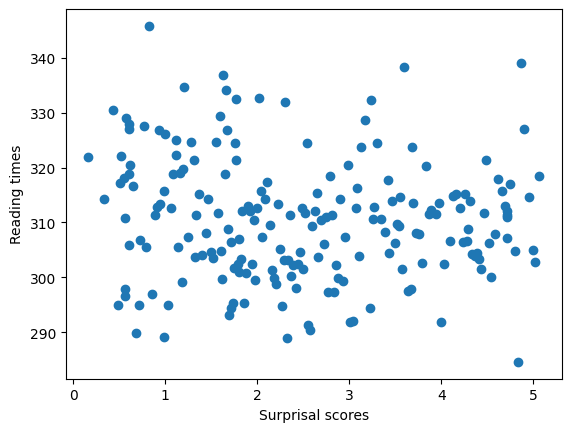

Pearson correlation: 0.1678


In [ ]:
import csv
import numpy as np
from collections import defaultdict
import arpa
import matplotlib.pyplot as plt
from scipy.stats import pearsonr as stats

def get_bigrams_and_reading_times(path_to_corpus):
    """
    path_to_corpus: str -- path to where the corpus is.

    Return a tuple of (bigrams, reading_times), where bigrams is a list of tuple of str
    and reading_times is a list of float of reading times. The reading time in bigrams
    indicates the mean reading time of the bigram at the same index in sentences.

    Note: Entries in bigrams may not be unique. If a given bigram occurs multiple times
        in the text, it will occur multiple times in the bigrams list. The corresponding
        reading times indicate the mean reading time of that bigram in the context it
        occurs in.
    Note: The first and last word in each sentence is excluded.
    Note: If an individual's reading time for a given bigram is an outlier (<80 or >1500),
        their score is discarded for that particular bigram.
    """
    context_id_to_bigram = {}
    context_id_to_reading_times = defaultdict(list)

    prev_word = None
    with open(path_to_corpus, "r") as csvfile:
        csv_reader = csv.DictReader(csvfile)
        for row in csv_reader:
            curr_word = row["word"].lower()
            if prev_word is None:
                prev_word = curr_word
                continue
            elif "." in prev_word:
                prev_word = None
                continue

            context_id = row["code"]
            reading_time = float(row["time"])
            if reading_time < 80 or reading_time > 1500:
                continue

            context_id_to_bigram[context_id] = (prev_word, curr_word)
            context_id_to_reading_times[context_id].append(reading_time)
            prev_word = curr_word

    bigrams = []
    reading_times = []
    for context_id, bigram in context_id_to_bigram.items():
        bigrams.append(bigram)
        reading_times.append(np.mean(context_id_to_reading_times[context_id]))

    return bigrams, reading_times

bigrams, reading_times = get_bigrams_and_reading_times("brown_reading_times.csv")

for i in range(min(10, len(bigrams))):
    print(f"Bigram: {bigrams[i]}, Average Reading Time: {reading_times[i]}")


model_with_smoothing = arpa.loadf("bnc_10k_with_smoothing.arpa")[0]
vocab = set(model_with_smoothing.vocabulary())

def compute_surprisal(arpa_model, bigram):
    (w1, w2) = bigram

    if w1 not in vocab or w2 not in vocab:
        return None
    try:
        prob_bigram = arpa_model.log_p([w1, w2])
        if prob_bigram is None or prob_bigram == 0:
            surprisal = 100000
        else:
            surprisal = np.log(1 / np.exp(prob_bigram))

    except KeyError:
        return None

    return surprisal

bigrams, reading_times = get_bigrams_and_reading_times("brown_reading_times.csv")

def compute_surprisal(arpa_model, bigram):
    w1, w2 = bigram
    if w1 not in vocab or w2 not in vocab:
        return None
    try:
        prob_bigram = arpa_model.log_p([w1, w2])
        if prob_bigram is None or prob_bigram == 0:
            surprisal = 100000
        else:
            surprisal = np.log(1 / np.exp(prob_bigram))
    except KeyError:
        return None

    return surprisal

surprisal_values = []
final_bigrams = []
final_reading_times = []

for i in range(len(bigrams)):
    surprisal = compute_surprisal(model_with_smoothing, bigrams[i])

    if surprisal is not None:
        surprisal_values.append(surprisal)
        final_bigrams.append(bigrams[i])
        final_reading_times.append(reading_times[i])


for i in range(min(10, len(final_bigrams))):
    print(f"Bigram: {final_bigrams[i]}, Surprisal: {surprisal_values[i]:.4f}, Reading Time: {final_reading_times[i]:.2f}")

def binned_scatter(scores, reading_times, n_bins=200):
    """
    scores: list of float -- mean surprisal score of a bigram
    reading_times: list of number -- mean reading time of a bigram
    n_bins: int -- number of bins to put points into

    Split the points into n_bins bins, based on their surprisal score
    in scores. Create a plot of surprisal score vs. reading time.
    """
    min_val = min(scores)
    max_val = max(scores)

    n_points = len(scores) // n_bins

    sorted_order = np.argsort(scores)
    sorted_scores = [scores[int(i)] for i in sorted_order]
    sorted_reading_times = [reading_times[int(i)] for i in reading_times]

    binned_scores = []
    binned_reading_times = []

    for i in range(n_bins):
        start = n_points * i
        end = n_points * (i + 1)
        binned_scores.append(np.mean(sorted_scores[start:end]))
        binned_reading_times.append(np.mean(sorted_reading_times[start:end]))

    plt.scatter(binned_scores, binned_reading_times)
    plt.ylabel("Reading Times")
    plt.xlabel("Surprisal Scores")
    plt.show()

binned_scatter(surprisal_values, final_reading_times, n_bins=200)

correlation, _ = pearsonr(surprisal_values, final_reading_times)
print(f"Pearson correlation: {correlation:.4f}")




### (d)

Using the same bigrams returned by `get_reading_times_and_bigrams` from part c, compute surprisal based on the BNC model **without** smoothing.

Generate a scatter plot and compute the linear correlation for the results without smoothing, as you did in part c. Do your results differ from the results in part c? If so, explain why, and if not, explain why not.

The correlation itself did not differ much as it was around 0.12 which is not that different from 0.1678. It would suggest that with no smoothing the positive correlation is even smoother. Something I thought was interesting was how all the points are on each side. I believe it basically boils down to you are either get it or you don't.

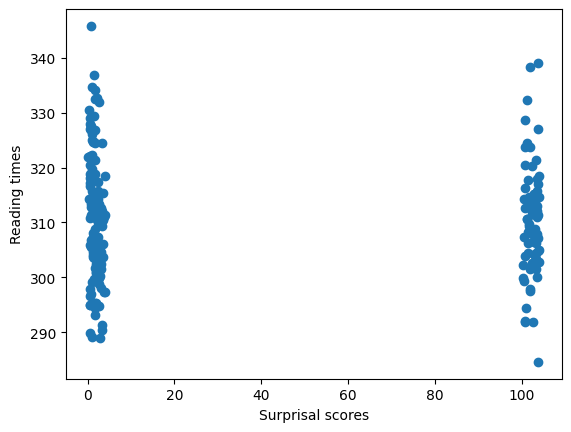

Pearson correlation: 0.1222


In [ ]:
from scipy.stats import pearsonr
from tqdm import tqdm
import csv
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import arpa

def get_bigrams_and_reading_times(path_to_corpus):
    """
    Extracts bigrams and their corresponding reading times from a CSV corpus.

    Args:
        path_to_corpus (str): Path to the CSV file.

    Returns:
        tuple: (bigrams, reading_times), where:
            - bigrams is a list of (word1, word2) tuples.
            - reading_times is a list of corresponding mean reading times.
    """
    context_id_to_bigram = {}
    context_id_to_reading_times = defaultdict(list)

    prev_word = None
    with open(path_to_corpus, "r") as csvfile:
        csv_reader = csv.DictReader(csvfile)
        for row in csv_reader:
            curr_word = row["word"].lower()
            if prev_word is None:
                prev_word = curr_word
                continue
            elif "." in prev_word:
                prev_word = None
                continue

            context_id = row["code"]
            reading_time = float(row["time"])
            if 80 <= reading_time <= 1500:
                context_id_to_bigram[context_id] = (prev_word, curr_word)
                context_id_to_reading_times[context_id].append(reading_time)

            prev_word = curr_word

    bigrams = list(context_id_to_bigram.values())
    reading_times = [np.mean(times) for times in context_id_to_reading_times.values()]

    return bigrams, reading_times



model_no_smoothing = arpa.loadf("bnc_10k_no_smoothing.arpa")[0]
vocab = set(model_no_smoothing.vocabulary())

def compute_surprisal(arpa_model, bigram):
    w1, w2 = bigram
    if w1 not in vocab or w2 not in vocab:
        return None
    try:
        prob_bigram = arpa_model.log_p([w1, w2])
        if prob_bigram is None or prob_bigram == 0:
            surprisal = 1000
        else:
            surprisal = np.log(1 / np.exp(prob_bigram))
    except KeyError:
        return None

    return surprisal

surprisal_values = []
final_bigrams = []
final_reading_times = []

for i in range(len(bigrams)):
    surprisal = compute_surprisal(model_no_smoothing, bigrams[i])

    if surprisal is not None:
        surprisal_values.append(surprisal)
        final_bigrams.append(bigrams[i])
        final_reading_times.append(reading_times[i])


def binned_scatter(scores, reading_times, n_bins=200):
    """
    scores: list of float -- mean surprisal score of a bigram
    reading_times: list of number -- mean reading time of a bigram
    n_bins: int -- number of bins to put points into

    Split the points into n_bins bins, based on their surprisal score
    in scores. Create a plot of surprisal score vs. reading time.
    """
    min_val = min(scores)
    max_val = max(scores)

    n_points = len(scores) // n_bins

    sorted_order = np.argsort(scores)
    sorted_scores = [scores[int(i)] for i in sorted_order]
    sorted_reading_times = [reading_times[int(i)] for i in reading_times]

    binned_scores = []
    binned_reading_times = []

    for i in range(n_bins):
        start = n_points * i
        end = n_points * (i + 1)
        binned_scores.append(np.mean(sorted_scores[start:end]))
        binned_reading_times.append(np.mean(sorted_reading_times[start:end]))

    plt.scatter(binned_scores, binned_reading_times)
    plt.ylabel("Reading Times")
    plt.xlabel("Surprisal Scores")
    plt.show()

binned_scatter(surprisal_values, final_reading_times, n_bins=200)

correlation, _ = pearsonr(surprisal_values, final_reading_times)
print(f"Pearson correlation: {correlation:.4f}")




## Part 3: Surprisal and Concreteness

Given the experiments we've done so far, we don't really know if surprisal is connected to semantics. One prominent element of semantics that cognitive scientists have found plays a role in word processing is concreteness. In the next part of the problem, we'll look at the relationship between surprisal and concreteness. To do this, we'll use the Calgary Concreteness data set$^4$, which has several English nouns and their concreteness ratings on a scale from 1 to 5. This dataset is in `data/calgary_concreteness.csv`.  We provide the functions that read in info from this dataset in `provided_functions.py`. Using this data, we can compare the average surprisal of words that are relatively high in concreteness to those that are relatively low in concreteness, to see how concreteness affects reading times.


### (e)

Write a function `compute_average_word_surprisal`, which computes the average surprisal for a given word based on `max_bigrams` randomly selected contexts that that word occurs in in the BNC corpus.

Use the function `compute_average_word_surprisal` to find the average surprisal for the word *cat*.

In [ ]:
import random
import numpy as np
from provided_functions import get_bigram_counts
import arpa

def compute_average_word_surprisal(word, bigram_counter, model, max_bigrams=100):
    """
    Computes the average surprisal for a given word based on max_bigrams
    randomly selected contexts in which that word appears at index 0.

    Args:
        word (str): The word to compute the average surprisal for.
        bigram_counter (collections.Counter): A Counter mapping bigram tuples to frequency.
        model (arpa model): The ARPA language model.
        max_bigrams (int): Number of sampled bigrams used to compute the average surprisal.

    Returns:
        float: The average surprisal value of the word in its bigram contexts.
    """
    vocab = set(model.vocabulary())
    wanted_bigrams = [bigram for bigram in bigram_counter if bigram[0] == word]

    valid_bigrams = [bigram for bigram in wanted_bigrams if bigram[1] in vocab]

    random.shuffle(valid_bigrams)
    sampled_bigrams = valid_bigrams[:max_bigrams]

    surprisal_values = []
    for bigram in sampled_bigrams:
        try:
            prob_bigram = model.log_p([bigram[0], bigram[1]])
            if prob_bigram is None:
                surprisal_values.append(100000)
            else:
                surprisal_values.append(np.log(1 / np.exp(prob_bigram)))
        except KeyError:
            continue

    return np.mean(surprisal_values) if surprisal_values else None

bigram_counts = get_bigram_counts("bnc_10k.txt")
model_with_smoothing = arpa.loadf("bnc_10k_with_smoothing.arpa")[0]

avg_surprisal = compute_average_word_surprisal("cat", bigram_counts, model_with_smoothing)

if avg_surprisal is not None:
    print(f"Average Surprisal for 'cat': {avg_surprisal:.4f}")
else:
    print("incorrect")

Average Surprisal for 'cat': 1.5168


### (f)

Take a look at the files `data/low_concreteness_nouns.txt` and `data/high_concreteness_nouns.txt`. These files each contain a subset of 100 nouns from the Calgary Concreteness data set with low concreteness (< 2.5), high concreteness (> 3.5) respectively. They are the most common nouns of each type based on frequency in the BNC sample.

Use `matplotlib` to generate a scatter plot of surprisal vs. concreteness for the low concreteness nouns in `data/low_concreteness_nouns.txt`. You should use `compute_average_word_surprisal` from part e as well as the functions `load_words`, `get_bigram_counts`, and `read_concreteness` defined in `provided_functions.py`.

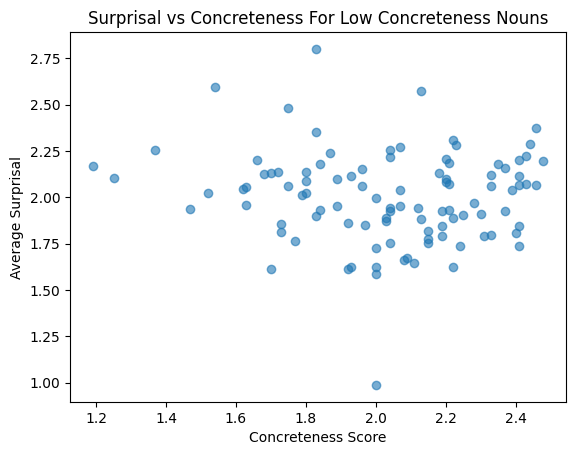

In [ ]:
import numpy as np
import random
import arpa
from collections import Counter, defaultdict
import csv
import string
import matplotlib.pyplot as plt

def load_words(path_to_file):
    """
    path_to_file: str -- path to one of the noun list files (e.g. 'data/all_nouns.txt')

    Return a list of all the words in the file at path_to_file.
    """
    with open(path_to_file, 'r') as f:
        words = f.readlines()
    return [item.strip() for item in words]

def get_bigram_counts(path_to_file):
    """
    path_to_file: str -- path to corpus file

    Return a Counter mapping bigram tuples to their frequency in the corpus at path_to_file.
    """
    result = Counter()
    with open(path_to_file, 'r') as f:
        for line in f:
            line = line.lower().split()
            for i in range(len(line) - 1):
                result.update([tuple(line[i: i + 2])])
    return result


def read_concreteness(path_to_file):
    """
    Reads the Calgary Concreteness data and returns a dictionary mapping words to their concreteness scores.
    """
    concreteness = []
    words = []

    with open(path_to_file, 'r') as csvfile:
        csv_reader = csv.reader(csvfile, delimiter=',')
        next(csv_reader)
        for row in csv_reader:
            words.append(row[0])
            concreteness.append(float(row[1]))

    concreteness_scores = {}
    for i in range(len(words)):
        concreteness_scores[words[i]] = concreteness[i]

    return concreteness_scores


low_concreteness_nouns = load_words("low_concreteness_nouns.txt")
bigram_counts = get_bigram_counts("bnc_10k.txt")
model_with_smoothing = arpa.loadf("bnc_10k_with_smoothing.arpa")[0]
concreteness_scores = read_concreteness("calgary_concreteness.csv")

def compute_average_word_surprisal(word, bigram_counter, model, max_bigrams=100):

    vocab = set(model.vocabulary())
    wanted_bigrams = [bigram for bigram in bigram_counter if bigram[0] == word]
    valid_bigrams = [bigram for bigram in wanted_bigrams if bigram[1] in vocab]

    random.shuffle(valid_bigrams)
    sampled_bigrams = valid_bigrams[:max_bigrams]

    surprisal_values = []
    for bigram in sampled_bigrams:
        try:
            prob_bigram = model.log_p([bigram[0], bigram[1]])
            if prob_bigram is None:
                surprisal_values.append(100000)
            else:
                surprisal_values.append(np.log(1 / np.exp(prob_bigram)))
        except KeyError:
            continue

    return np.mean(surprisal_values) if surprisal_values else None

surprisal_values = []
word_concreteness = []

for word in low_concreteness_nouns:
    av_surprisal = compute_average_word_surprisal(word, bigram_counts, model_with_smoothing)
    if av_surprisal is not None and word in concreteness_scores:
        surprisal_values.append(av_surprisal)
        word_concreteness.append(concreteness_scores[word])

plt.scatter(word_concreteness, surprisal_values, alpha=0.6)
plt.xlabel("Concreteness Score")
plt.ylabel("Average Surprisal")
plt.title("Surprisal vs Concreteness For Low Concreteness Nouns")
plt.show()


### (g)

Use the same approach that you used in part f to generate a scatter plot of surprisal vs. concreteness the nouns in `data/high_concreteness_nouns.txt`.

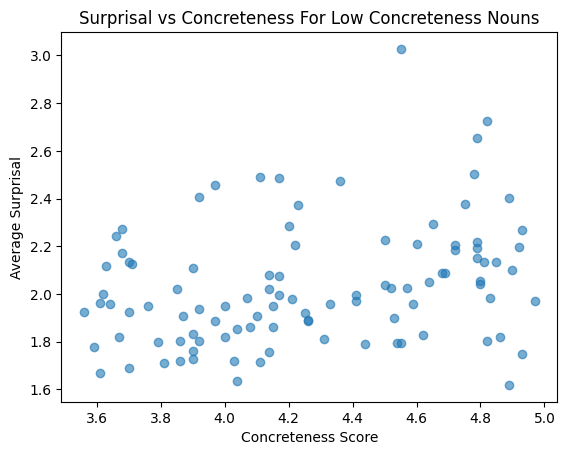

In [ ]:
import numpy as np
import random
import arpa
from collections import Counter, defaultdict
import csv
import string
import matplotlib.pyplot as plt

def load_words(path_to_file):
    """
    path_to_file: str -- path to one of the noun list files (e.g. 'data/all_nouns.txt')

    Return a list of all the words in the file at path_to_file.
    """
    with open(path_to_file, 'r') as f:
        words = f.readlines()
    return [item.strip() for item in words]

def get_bigram_counts(path_to_file):
    """
    path_to_file: str -- path to corpus file

    Return a Counter mapping bigram tuples to their frequency in the corpus at path_to_file.
    """
    result = Counter()
    with open(path_to_file, 'r') as f:
        for line in f:
            line = line.lower().split()
            for i in range(len(line) - 1):
                result.update([tuple(line[i: i + 2])])
    return result


def read_concreteness(path_to_file):
    """
    Reads the Calgary Concreteness data and returns a dictionary mapping words to their concreteness scores.
    """
    concreteness = []
    words = []

    with open(path_to_file, 'r') as csvfile:
        csv_reader = csv.reader(csvfile, delimiter=',')
        next(csv_reader)
        for row in csv_reader:
            words.append(row[0])
            concreteness.append(float(row[1]))

    concreteness_scores = {}
    for i in range(len(words)):
        concreteness_scores[words[i]] = concreteness[i]

    return concreteness_scores


high_concreteness_nouns = load_words("high_concreteness_nouns.txt")
bigram_counts = get_bigram_counts("bnc_10k.txt")
model_with_smoothing = arpa.loadf("bnc_10k_with_smoothing.arpa")[0]
concreteness_scores = read_concreteness("calgary_concreteness.csv")

def compute_average_word_surprisal(word, bigram_counter, model, max_bigrams=100):

    vocab = set(model.vocabulary())
    wanted_bigrams = [bigram for bigram in bigram_counter if bigram[0] == word]
    valid_bigrams = [bigram for bigram in wanted_bigrams if bigram[1] in vocab]

    random.shuffle(valid_bigrams)
    sampled_bigrams = valid_bigrams[:max_bigrams]

    surprisal_values = []
    for bigram in sampled_bigrams:
        try:
            prob_bigram = model.log_p([bigram[0], bigram[1]])
            if prob_bigram is None:
                surprisal_values.append(100000)
            else:
                surprisal_values.append(np.log(1 / np.exp(prob_bigram)))
        except KeyError:
            continue

    return np.mean(surprisal_values) if surprisal_values else None

surprisal_values = []
word_concreteness = []

for word in high_concreteness_nouns:
    av_surprisal = compute_average_word_surprisal(word, bigram_counts, model_with_smoothing)
    if av_surprisal is not None and word in concreteness_scores:
        surprisal_values.append(av_surprisal)
        word_concreteness.append(concreteness_scores[word])

plt.scatter(word_concreteness, surprisal_values, alpha=0.6)
plt.xlabel("Concreteness Score")
plt.ylabel("Average Surprisal")
plt.title("Surprisal vs Concreteness For Low Concreteness Nouns")
plt.show()


### (h)

What is the relationship between surprisal and concreteness? Is the relationship different for high and low concreteness nouns? Explain why you think this is or is not the case.

The relationship between surprisal and concreteness was what appears a negative correlation. For high concreteness the suprisal appeared to be lower as compared to high. I think the reason is self-evident in that when you can visualise something more directly it is going to less unpredictable as opposed to an intangible concept.

### Citations

$^1$Smith, N. J., & Levy, R. (2013). The effect of word predictability on reading time is logarithmic. Cognition, 128(3), 302-319. doi:10.1016/j.cognition.2013.02.013

$^2$The British National Corpus, version 3 (BNC XML Edition). 2007. Distributed by Bodleian Libraries, University of Oxford, on behalf of the BNC Consortium. URL: http://www.natcorp.ox.ac.uk/

$^3$A Standard Corpus of Present-Day Edited American English, for use with Digital Computers (Brown). 1964, 1971, 1979. Compiled by W. N. Francis and H. Kučera. Brown University. Providence, Rhode Island.

$^4$Pexman, P. M., Heard, A., Lloyd, E., & Yap, M. J. (2016). The Calgary semantic decision project: Concrete/abstract decision data for 10,000 English words. Behavior Research Methods, 49(2), 407-417. doi:10.3758/s13428-016-0720-6